In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../../ml_data/churn_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          4250 non-null   object 
 1   account_length                 4250 non-null   int64  
 2   area_code                      4250 non-null   object 
 3   international_plan             4250 non-null   object 
 4   voice_mail_plan                4250 non-null   object 
 5   number_vmail_messages          4250 non-null   int64  
 6   total_day_minutes              4250 non-null   float64
 7   total_day_calls                4250 non-null   int64  
 8   total_day_charge               4250 non-null   float64
 9   total_eve_minutes              4250 non-null   float64
 10  total_eve_calls                4250 non-null   int64  
 11  total_eve_charge               4250 non-null   float64
 12  total_night_minutes            4250 non-null   f

In [4]:
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0


In [5]:
# Binary encoding for internaltional_plan and voice_mail_plan
df['international_plan'] = df['international_plan'].replace({'yes': 1, 'no': 0})
df['voice_mail_plan'] = df['voice_mail_plan'].replace({'yes': 1, 'no': 0})

In [6]:
df.shape

(4250, 20)

In [7]:
# check for missing data
df.isnull().sum()

state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
churn                            0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_length,4250.0,100.236235,39.698401,1.0,73.0000,100.00,127.0000,243.00
international_plan,4250.0,0.093176,0.290714,0.0,0.0000,0.00,0.0000,1.00
voice_mail_plan,4250.0,0.261647,0.439583,0.0,0.0000,0.00,1.0000,1.00
number_vmail_messages,4250.0,7.631765,13.439882,0.0,0.0000,0.00,16.0000,52.00
total_day_minutes,4250.0,180.259600,54.012373,0.0,143.3250,180.45,216.2000,351.50
total_day_calls,4250.0,99.907294,19.850817,0.0,87.0000,100.00,113.0000,165.00
total_day_charge,4250.0,30.644682,9.182096,0.0,24.3650,30.68,36.7500,59.76
total_eve_minutes,4250.0,200.173906,50.249518,0.0,165.9250,200.70,233.7750,359.30
total_eve_calls,4250.0,100.176471,19.908591,0.0,87.0000,100.00,114.0000,170.00
total_eve_charge,4250.0,17.015012,4.271212,0.0,14.1025,17.06,19.8675,30.54


In [9]:
df = df.drop(axis=1, columns=['state', 'area_code'])

In [10]:
df.churn.value_counts(normalize=True) 
#Target variable "churn" shows imbalance; only 14.07% of observations indicate churn.

churn
0    0.859294
1    0.140706
Name: proportion, dtype: float64

In [11]:
df.columns


Index(['account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls', 'churn'],
      dtype='object')

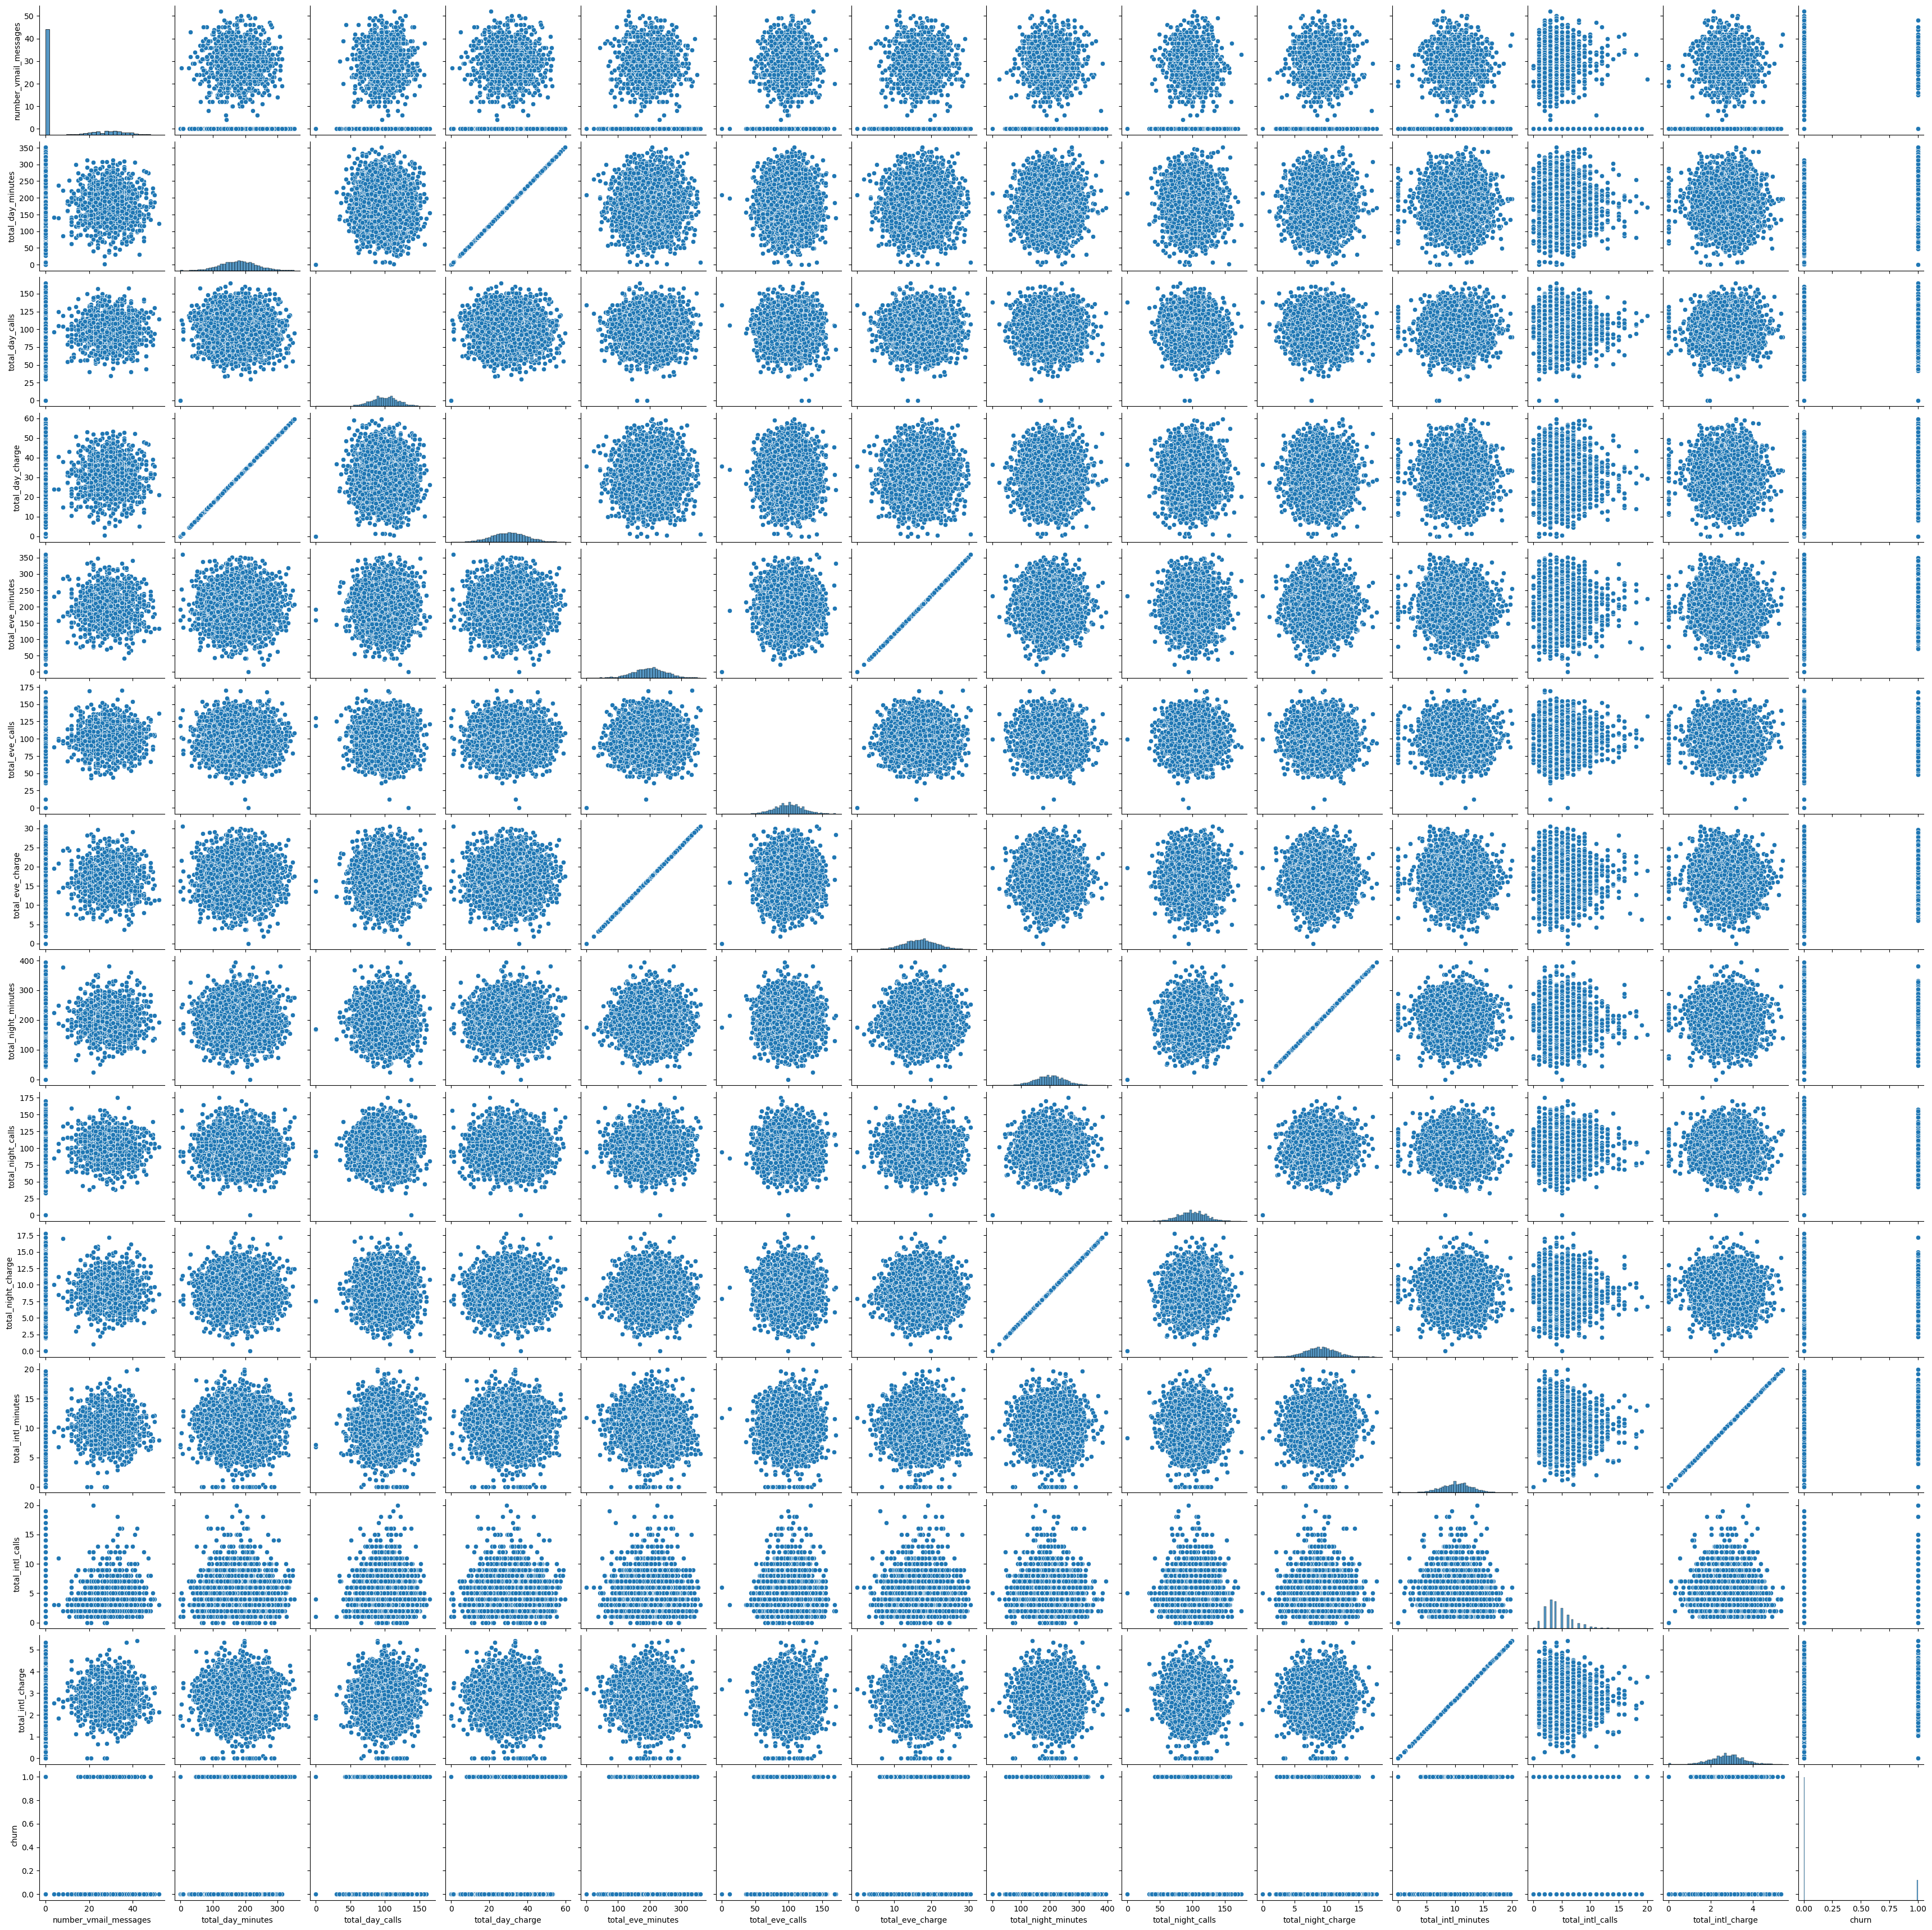

In [12]:
# sns.pairplot(data=df, vars=df.select_dtypes(include=[np.number]));

sns.pairplot(data=df, vars=['number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge','churn']);

<Axes: xlabel='total_day_minutes', ylabel='Count'>

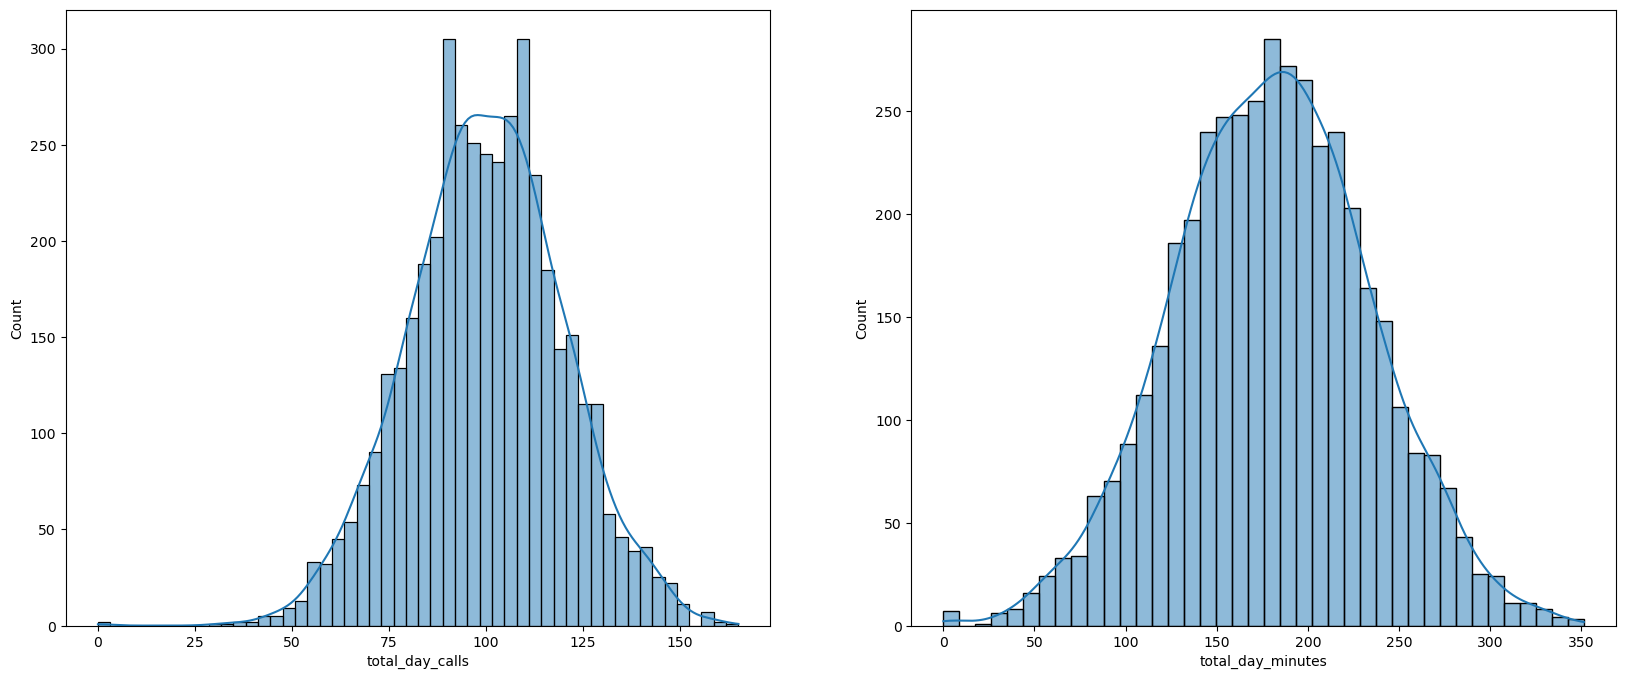

In [13]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(121)
sns.histplot(df['total_day_calls'], kde=True)

ax = fig.add_subplot(122)
sns.histplot(df['total_day_minutes'], kde=True)

<Axes: xlabel='voice_mail_plan', ylabel='count'>

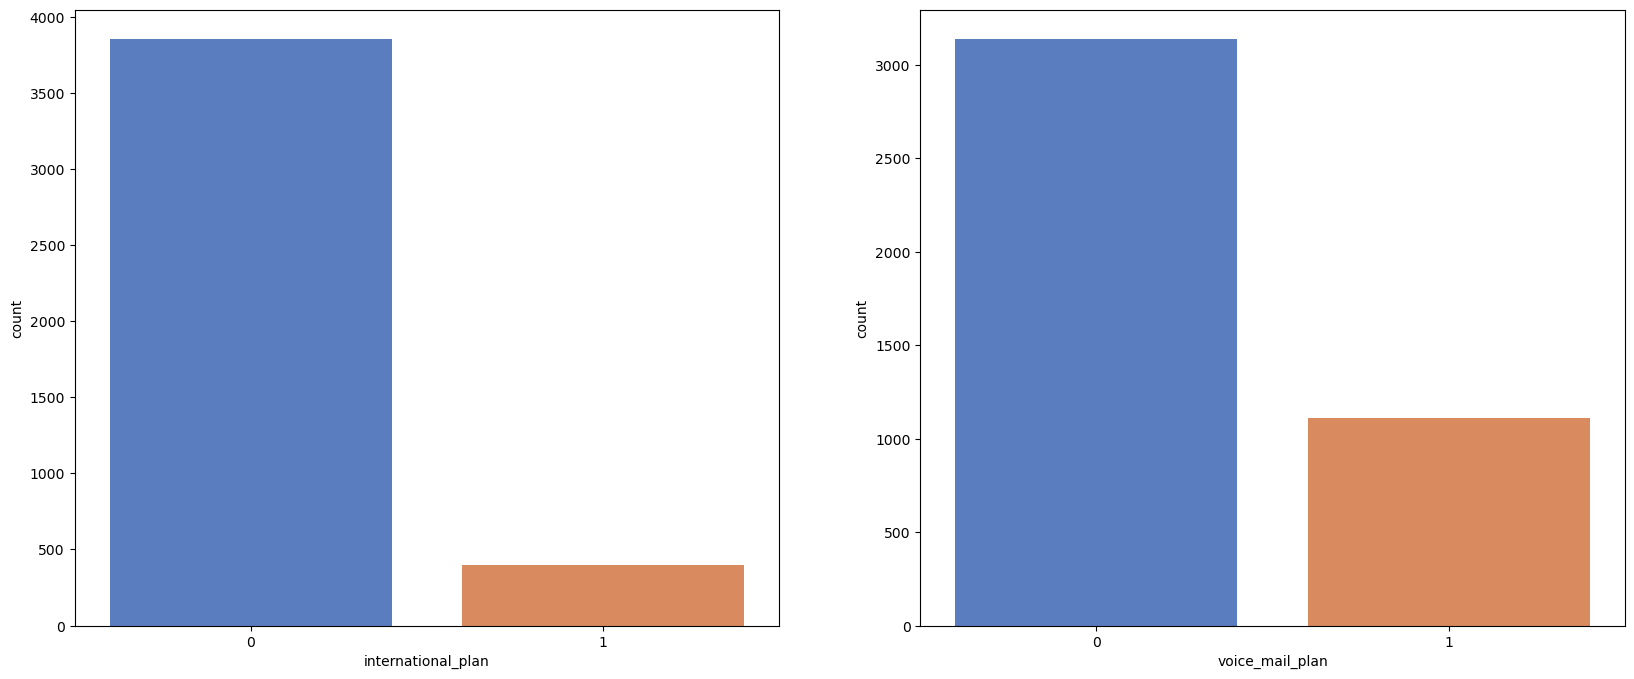

In [14]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121)
sns.countplot(data=df, x="international_plan",palette="muted")

ax = fig.add_subplot(122)
sns.countplot(data=df, x="voice_mail_plan",palette="muted")

#### **Imbalanced Data**
- An imbalanced dataset refers to a dataset where the distribution of observations across different classes is highly skewed, with one class significantly outnumbering the others. In other words, there is a disproportionate representation of classes within the dataset. Typically, one class, known as the majority class, has a much larger number of observations compared to the minority class or classes.
- For example, in a binary classification problem where the goal is to predict whether a transaction is fraudulent (Class 1) or not (Class 0), an imbalanced dataset may have only a small percentage of fraudulent transactions compared to the vast majority of non-fraudulent ones. In this scenario, the fraudulent class constitutes the minority class, while the non-fraudulent class represents the majority class.

<Axes: xlabel='churn', ylabel='total_night_calls'>

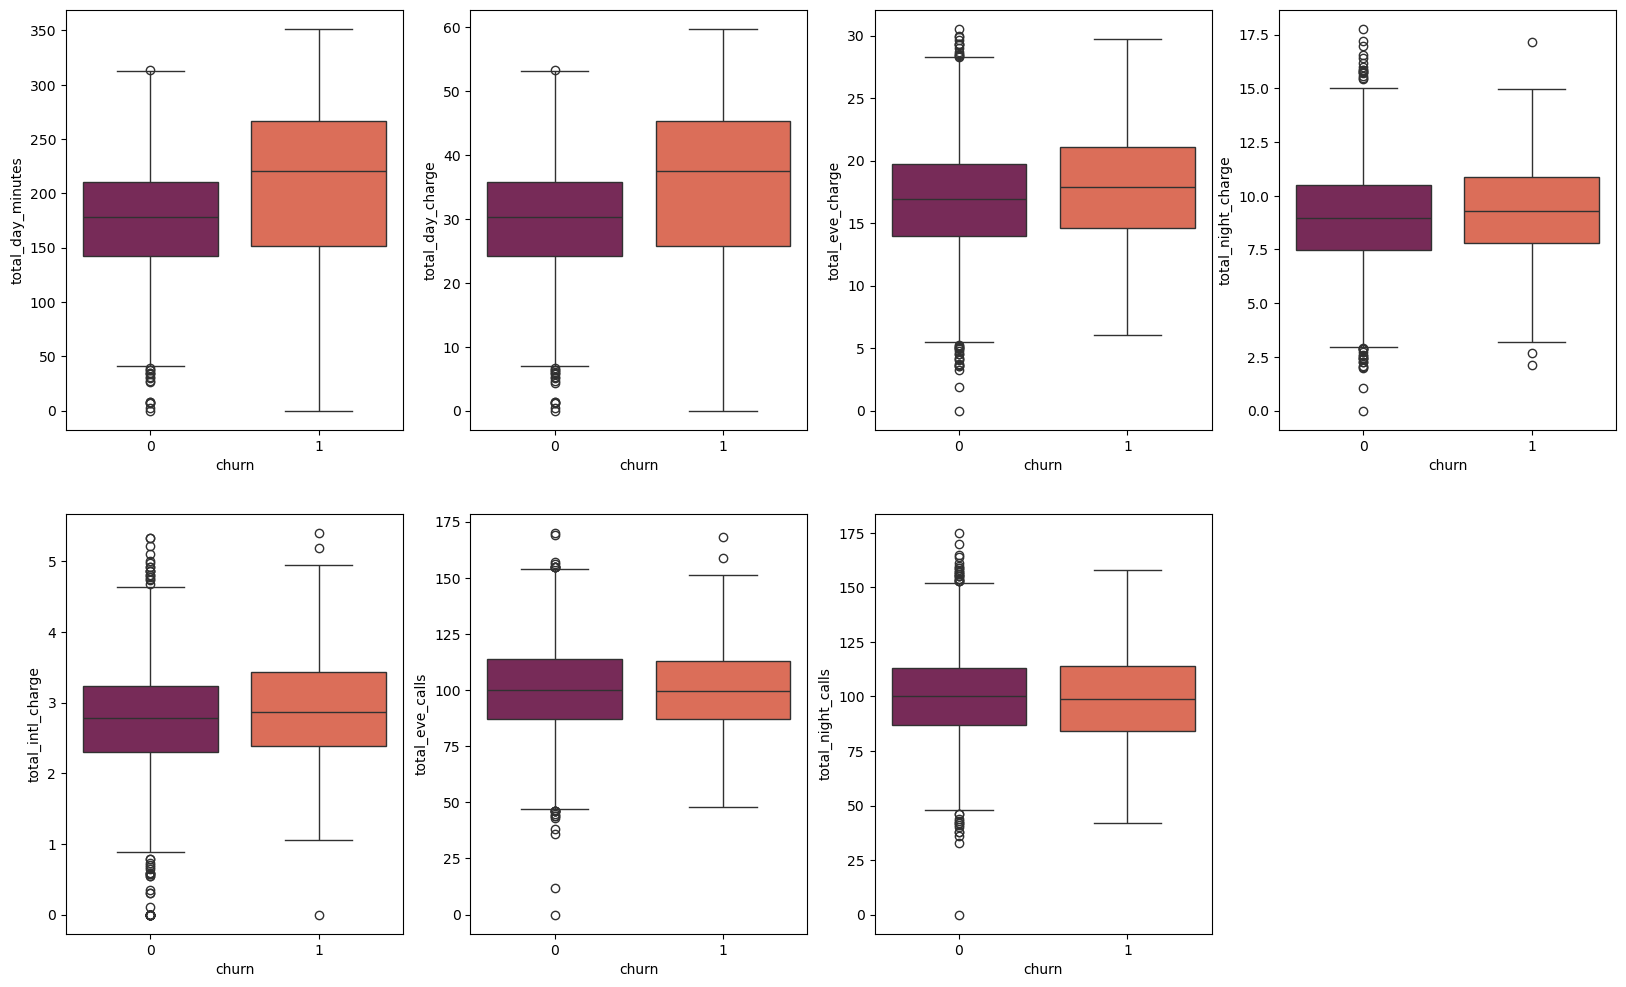

In [15]:
plt.figure(figsize=(20, 12))
plt.subplot(2,4,1)
sns.boxplot(x = 'churn', y = 'total_day_minutes', data = df, palette="rocket")
plt.subplot(2,4,2)
sns.boxplot(x = 'churn', y = 'total_day_charge', data = df, palette="rocket")
plt.subplot(2,4,3)
sns.boxplot(x = 'churn', y = 'total_eve_charge', data = df, palette="rocket")
plt.subplot(2,4,4)
sns.boxplot(x = 'churn', y = 'total_night_charge', data = df, palette="rocket")
plt.subplot(2,4,5)
sns.boxplot(x = 'churn', y = 'total_intl_charge', data = df, palette="rocket")
plt.subplot(2,4,6)
sns.boxplot(x = 'churn', y = 'total_eve_calls', data = df, palette="rocket")
plt.subplot(2,4,7)
sns.boxplot(x = 'churn', y = 'total_night_calls', data = df, palette="rocket")

In [16]:
corr_matrix = df.corr()

<Axes: >

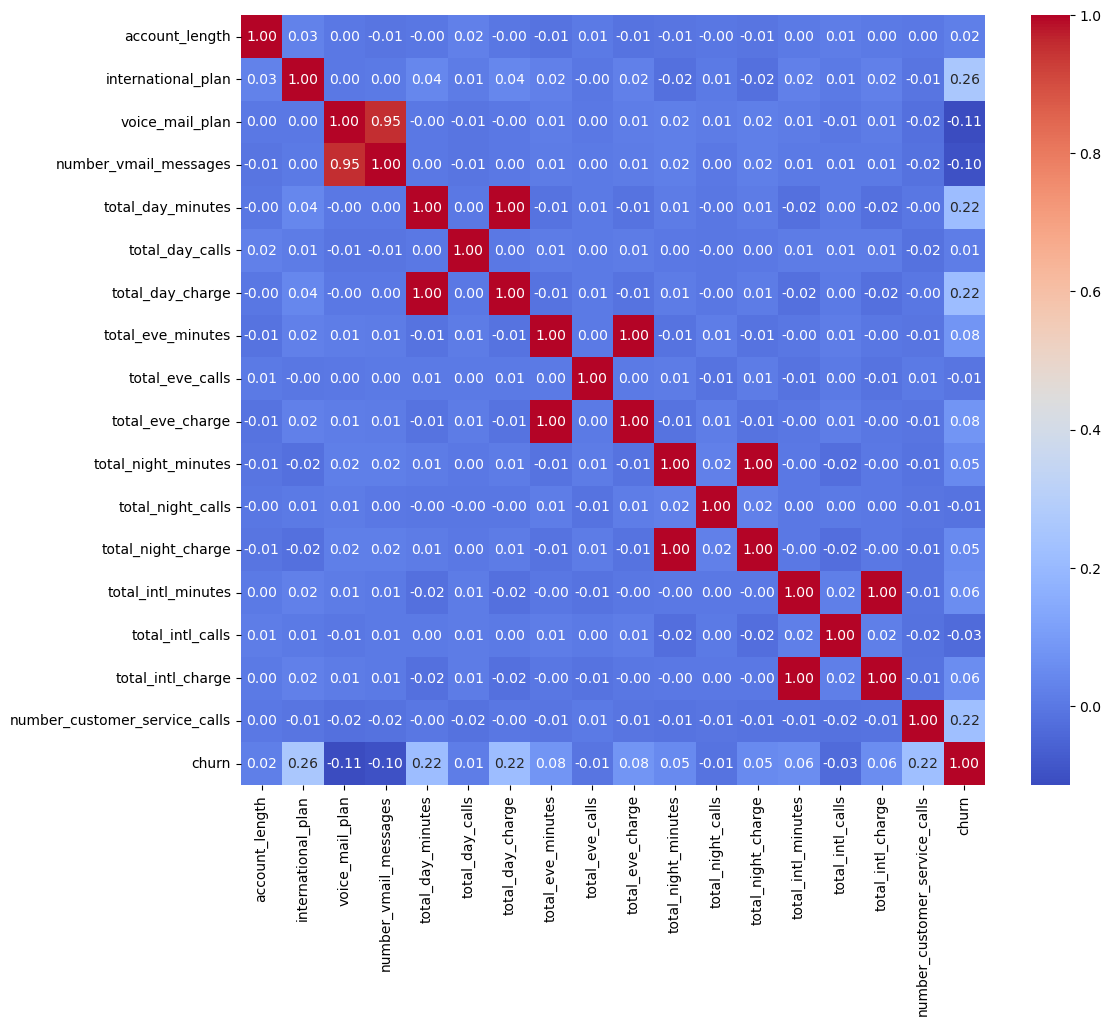

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

In [18]:
target = df['churn']

X = df.drop(['churn'], axis=1)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=1)

In [21]:
logit = LogisticRegression()

logit.fit(X_train, y_train)

LogisticRegression()

In [22]:
logit.intercept_

array([-0.49491088])

In [23]:
logit.coef_

array([[-2.53529409e-03,  2.00913784e+00, -2.50482176e-01,
        -2.44243354e-02,  9.75088023e-03, -1.30768379e-02,
        -1.10664159e-03,  1.42118084e-03, -1.41260047e-02,
         3.93297581e-04,  2.03561665e-04, -1.49149717e-02,
        -1.51262387e-03,  5.15565170e-02, -1.11505588e-01,
         1.32216098e-02,  4.49488818e-01]])

In [24]:
import statsmodels.api as sm

In [25]:
X_train_sm = sm.add_constant(X_train)

sm_model = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.308701
         Iterations 8


In [26]:
print(sm_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 3400
Model:                          Logit   Df Residuals:                     3382
Method:                           MLE   Df Model:                           17
Date:                Mon, 19 Jan 2026   Pseudo R-squ.:                  0.2407
Time:                        18:41:49   Log-Likelihood:                -1049.6
converged:                       True   LL-Null:                       -1382.3
Covariance Type:            nonrobust   LLR p-value:                1.893e-130
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -8.9220      0.728    -12.258      0.000     -10.349      -7.495
account_length                    0.0008      0.001      0.579      0.563 

In [27]:
coef_sm = pd.read_html(sm_model.summary().tables[1].as_html(), header=0, index_col=0)[0]

ImportError: Missing optional dependency 'lxml'.  Use pip or conda to install lxml.

In [28]:
X_test_sm = sm.add_constant(X_test)

In [29]:
pred_sm = sm_model.predict(X_test_sm)

In [30]:
pred = np.where(pred_sm > 0.5, 1, 0)

In [31]:
y_pred = logit.predict(X_test)

In [32]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [33]:
print("Stat model")
print(confusion_matrix(y_test, pred))

# Calculate and print the confusion matrix using predictions from scikit-learn model
print(confusion_matrix(y_test, y_pred))

Stat model
[[711  20]
 [ 98  21]]
[[714  17]
 [ 93  26]]


In [34]:
precision_score(y_test, y_pred)

0.6046511627906976

In [35]:
recall_score(y_test, y_pred)

0.2184873949579832

In [36]:
from sklearn.metrics import roc_curve, auc

In [37]:
# Predict class probabilities for the testing data using the trained logistic regression model
y_pred = logit.predict_proba(X_test)

y_pred

array([[0.9450646 , 0.0549354 ],
       [0.96283804, 0.03716196],
       [0.92588611, 0.07411389],
       ...,
       [0.80379401, 0.19620599],
       [0.96493656, 0.03506344],
       [0.95176373, 0.04823627]], shape=(850, 2))

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred[:,1], pos_label=1)

roc_auc = auc(fpr, tpr)

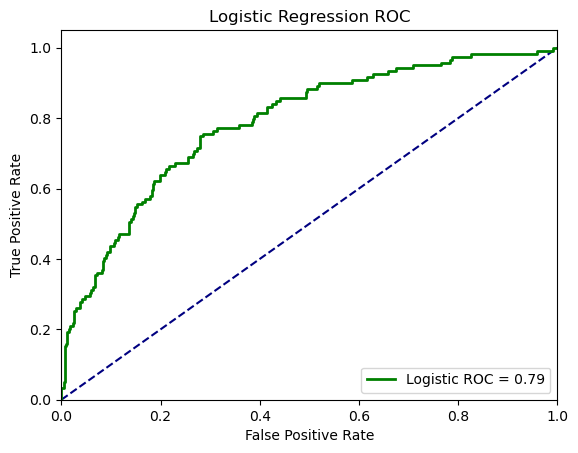

In [42]:
# ROC Graph Data
plt.figure()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0,1], color='navy', linestyle='--')  # Diagonal line representing random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Logistic Regression ROC")
plt.plot(fpr, tpr, color='green', lw=2, label='Logistic ROC = %0.2f' % roc_auc)  # Plotting ROC curve
plt.legend(loc='lower right')

In [43]:
y_pred = sm_model.predict(X_test_sm)

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
roc_auc = auc(fpr, tpr)

In [45]:
# Variable selected (just by intuition)
cols = ['total_day_minutes', 'total_eve_minutes', 'number_customer_service_calls', 'international_plan', 'number_vmail_messages']  # Selected columns
X_tr = X_train[cols]  # Features selected for training data
X_te = X_test[cols]   # Features selected for testing data

# Print the column names of the selected features for training data
print("Selected features for training data:")
print(X_tr.columns)

Selected features for training data:
Index(['total_day_minutes', 'total_eve_minutes',
       'number_customer_service_calls', 'international_plan',
       'number_vmail_messages'],
      dtype='object')


In [46]:
logmodel = LogisticRegression()
logmodel.fit(X_tr, y_train)

LogisticRegression()

In [47]:
logmodel.coef_

array([[ 0.01367113,  0.00637418,  0.5138548 ,  2.03288792, -0.03187803]])

In [48]:
pred = logmodel.predict(X_te)

In [49]:
confusion_matrix(y_test, pred)

array([[712,  19],
       [ 99,  20]])

In [50]:
prob = logmodel.predict_proba(X_te)

In [51]:
# change cutoff to .3
pred = np.where(prob[:, 1] > 0.3, 1, 0)

In [52]:
confusion_matrix(y_test, pred)

array([[669,  62],
       [ 64,  55]])

In [53]:
precision_score(y_test, pred)

0.4700854700854701

In [54]:
recall_score(y_test, pred)

0.46218487394957986

In [55]:
# Predict class probabilities for the testing data using the logistic regression model
y_pred = logmodel.predict_proba(X_te)

# Compute the ROC curve using the predicted probabilities and true labels for the positive class
lr_fpr, lr_tpr, thresholds = roc_curve(y_test, y_pred[:,1], pos_label=1)

# Calculate the area under the ROC curve (AUC)
lr_roc_auc = auc(lr_fpr, lr_tpr)

In [56]:
lr_roc_auc

np.float64(0.8106427249422341)

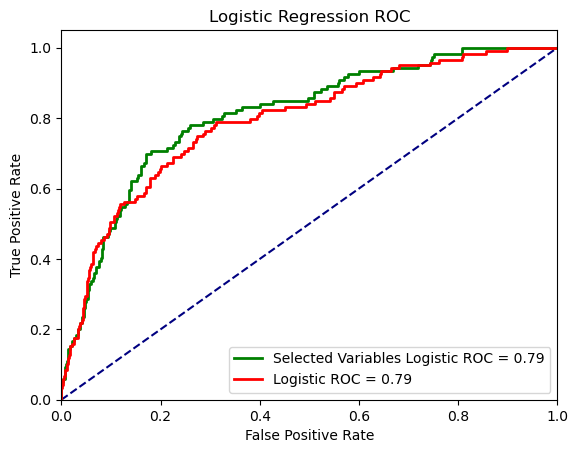

In [57]:
# ROC Graph Data
plt.figure()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0,1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Logistic Regression ROC")
plt.plot(lr_fpr, lr_tpr, color='green', lw=2, label='Selected Variables Logistic ROC = %0.2f' % roc_auc)  # corrected line
plt.plot(fpr, tpr, color='red', lw=2, label='Logistic ROC = %0.2f' % roc_auc)  # corrected line
plt.legend(loc ='lower right')